# **Resume–Job Description Matching System using Bi-Directional LSTM**

### **Project Objective**

The objective of this project is to build an intelligent resume–job description matching system using a **Bi-Directional LSTM (BiLSTM)** architecture and similarity-based ranking. The goal is to transform unstructured resume text and job descriptions into meaningful sequence representations, allowing the model to evaluate semantic alignment between candidate profiles and role requirements. This project aims to simulate how modern applicant tracking and talent intelligence systems can move beyond keyword matching and perform context-aware ranking of resumes for a given job description.

### **Dataset Used**

The dataset used in this project is the **Resume Dataset by PromptCloudHQ**, available at:

**Dataset Link:** https://www.kaggle.com/datasets/PromptCloudHQ/resume-dataset

The dataset primarily contains resume text data across different job categories or functional domains. Since the raw dataset focuses on resume content rather than explicit resume–job matching labels, this project uses the dataset in a structured ranking workflow:

- resume documents are loaded and cleaned
- resume categories are analyzed and standardized
- synthetic or templated job descriptions are created from role families to simulate hiring use cases
- positive and negative resume–job pairs are constructed for supervised similarity learning
- train, validation, and test splits are created for controlled experimentation
- the trained BiLSTM model produces dense representations for resumes and job descriptions
- cosine similarity and top-k ranking are used to retrieve the most relevant resumes for each job description

This setup reflects a common applied NLP scenario where direct pairwise labels are not readily available and must be engineered from realistic domain structure.

### **Project Summary**

This project develops an end-to-end resume ranking system using a **BiLSTM-based Siamese / dual-encoder style design**. Resumes and job descriptions are independently tokenized and passed through embedding and BiLSTM layers so that each text is encoded into a dense semantic representation. These representations are then compared using similarity scoring to estimate how well a given resume matches a specific job description.

A key challenge in this task is that resumes and job descriptions differ substantially in writing style, structure, and granularity. Resumes often emphasize prior experience, skills, certifications, and projects, whereas job descriptions emphasize expectations, responsibilities, and desired qualifications. The BiLSTM architecture is particularly useful here because it captures both forward and backward context, helping the model learn richer sequence patterns than simple bag-of-words methods.

The project includes dataset analysis, resume text cleaning, tokenization, vocabulary construction, sequence padding, pair generation, training of a BiLSTM ranking model, evaluation using both classification and ranking metrics, and practical inference utilities. It also includes top-k matching examples, error analysis, and an optional deployment demo section so the notebook can serve as both a learning artifact and a portfolio-ready applied AI project.

### **Key Highlights**

- Built a **resume–job description ranking system** using **Bi-Directional LSTM** sequence encoders.
- Used the **PromptCloudHQ Resume Dataset** as the core resume corpus for semantic matching.
- Designed a **pair-construction strategy** to create positive and negative resume–JD examples for supervised learning.
- Implemented **tokenization, vocabulary building, padding, and sequence preprocessing** for both resumes and job descriptions.
- Built a **BiLSTM-based similarity model** for semantic matching.
- Evaluated the system using **accuracy, precision, recall, F1-score, Recall@K, and ranking inspection**.
- Added **cosine similarity scoring** and **top-k resume retrieval** to simulate ATS-style ranking.
- Included **sample outputs**, **error analysis**, and an optional **deployment demo** section.
- Preserved a modular workflow so the project can be extended into recommendation systems, recruiter copilots, or hiring dashboards.


### **Install Required Libraries**

In [1]:
!pip -q install -U pandas numpy matplotlib scikit-learn nltk ipywidgets tensorflow keras streamlit

### **Import Core Libraries**

In [2]:
import os
import gc
import re
import json
import math
import random
import string
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    GlobalMaxPooling1D,
    Concatenate,
    Lambda,
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.saving import register_keras_serializable

warnings.filterwarnings("ignore")

@register_keras_serializable(package="Custom")
def absolute_difference_fn(tensors):
    return tf.abs(tensors[0] - tensors[1])

@register_keras_serializable(package="Custom")
def elementwise_product_fn(tensors):
    return tensors[0] * tensors[1]


### **Notebook Display Settings**

In [3]:
pd.set_option("display.max_colwidth", 240)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

### **Set Reproducibility Seed**

In [4]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)

Seed set to: 42


### **Create Project Folders**

In [5]:
PROJECT_DIR = Path("./resume_job_matching_bilstm_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "saved_model"
PRED_DIR = PROJECT_DIR / "predictions"

for folder in [PROJECT_DIR, ARTIFACT_DIR, MODEL_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


### **Define Project Configuration**

In [6]:
DATA_ROOT = Path("./resume_dataset")
DATA_FILE = DATA_ROOT / "resume_dataset.csv"

MAX_VOCAB_SIZE = 25000
MAX_RESUME_LEN = 300
MAX_JD_LEN = 220
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.30
BATCH_SIZE = 32
EPOCHS = 4
TOP_K = 5

print("Configuration ready.")

Configuration ready.


### **State the Real-World Problem**

In [7]:
problem_statement = '''
Hiring teams often receive large numbers of resumes for a single opening. Traditional keyword-based
screening can miss semantically relevant candidates and overvalue exact phrase overlap. This project
addresses that limitation by using a Bi-Directional LSTM model to learn richer representations of
resumes and job descriptions so that resumes can be ranked based on contextual alignment rather than
pure keyword matching.
'''
print(problem_statement)


Hiring teams often receive large numbers of resumes for a single opening. Traditional keyword-based
screening can miss semantically relevant candidates and overvalue exact phrase overlap. This project
addresses that limitation by using a Bi-Directional LSTM model to learn richer representations of
resumes and job descriptions so that resumes can be ranked based on contextual alignment rather than
pure keyword matching.



### **Show Expected Dataset Structure**

In [8]:
expected_structure = '''
resume_dataset/
└── resume_dataset.csv

Expected columns may vary by source, but commonly include:
- Resume_str
- Category
'''
print(expected_structure)


resume_dataset/
└── resume_dataset.csv

Expected columns may vary by source, but commonly include:
- Resume_str
- Category



### **Create a Small Placeholder Dataset if Missing**

In [9]:
if not DATA_FILE.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    sample_df = pd.DataFrame({
        "Category": [
            "Data Science", "Data Science", "HR", "Java Developer",
            "Python Developer", "Sales", "DevOps Engineer", "Testing"
        ],
        "Resume_str": [
            "Experienced data scientist with python machine learning sql power bi deep learning and model deployment experience.",
            "Worked on analytics statistics machine learning feature engineering and dashboarding for business decision making.",
            "Human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience.",
            "Java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise.",
            "Python developer with flask django pandas api development automation testing and scripting experience.",
            "Sales professional with business development client management lead generation negotiation and crm handling.",
            "DevOps engineer skilled in ci cd docker kubernetes aws monitoring infrastructure automation and linux.",
            "QA engineer with manual testing automation selenium jira test cases regression and bug tracking."
        ]
    })

    sample_df.to_csv(DATA_FILE, index=False)
    print("Created a placeholder dataset for notebook structure.")
else:
    print("Dataset file already exists.")

Dataset file already exists.


### **Load the Resume Dataset**

In [10]:
df = pd.read_csv(DATA_FILE)
print(df.shape)
df.head()

(8, 2)


,Category,Resume_str
0,Data Science,Experienced data scientist with python machine learning sql power bi deep learning and model deployment experience.
1,Data Science,Worked on analytics statistics machine learning feature engineering and dashboarding for business decision making.
2,HR,Human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience.
3,Java Developer,Java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise.
4,Python Developer,Python developer with flask django pandas api development automation testing and scripting experience.


### **Inspect Dataset Columns**

In [11]:
df.columns.tolist()

['Category', 'Resume_str']

### **Rename Columns to Standard Names**

In [12]:
column_map = {}
for col in df.columns:
    lower_col = col.lower()
    if "resume" in lower_col:
        column_map[col] = "resume_text"
    elif "category" in lower_col:
        column_map[col] = "category"

df = df.rename(columns=column_map)
df.head()

,category,resume_text
0,Data Science,Experienced data scientist with python machine learning sql power bi deep learning and model deployment experience.
1,Data Science,Worked on analytics statistics machine learning feature engineering and dashboarding for business decision making.
2,HR,Human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience.
3,Java Developer,Java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise.
4,Python Developer,Python developer with flask django pandas api development automation testing and scripting experience.


### **Check Missing Values**

In [13]:
df.isna().sum()

category       0
resume_text    0
dtype: int64

### **Drop Missing Resume Rows**

In [14]:
df = df.dropna(subset=["resume_text"]).reset_index(drop=True)
print(df.shape)

(8, 2)


### **Inspect Category Distribution**

In [15]:
df["category"].value_counts()

category
Data Science        2
HR                  1
Java Developer      1
Python Developer    1
Sales               1
DevOps Engineer     1
Testing             1
Name: count, dtype: int64

### **Plot Category Distribution**

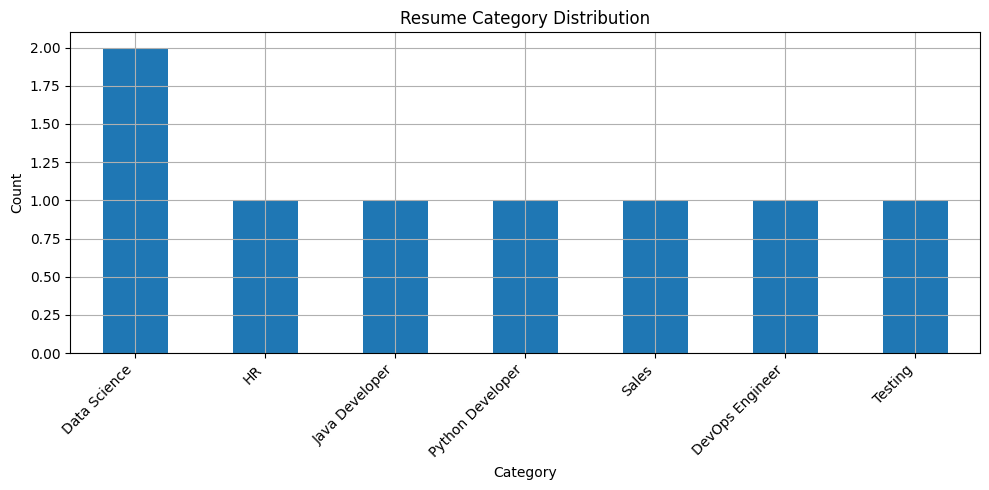

In [16]:
df["category"].value_counts().plot(kind="bar")
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Create Resume Length Features**

In [17]:
df["resume_char_len"] = df["resume_text"].astype(str).str.len()
df["resume_word_len"] = df["resume_text"].astype(str).str.split().str.len()
df[["resume_char_len", "resume_word_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
resume_char_len,8.0,107.75,7.106335,96.0,102.0,109.0,114.25,115.0
resume_word_len,8.0,14.00,1.069045,13.0,13.0,14.0,14.25,16.0


### **Plot Resume Word Length Distribution**

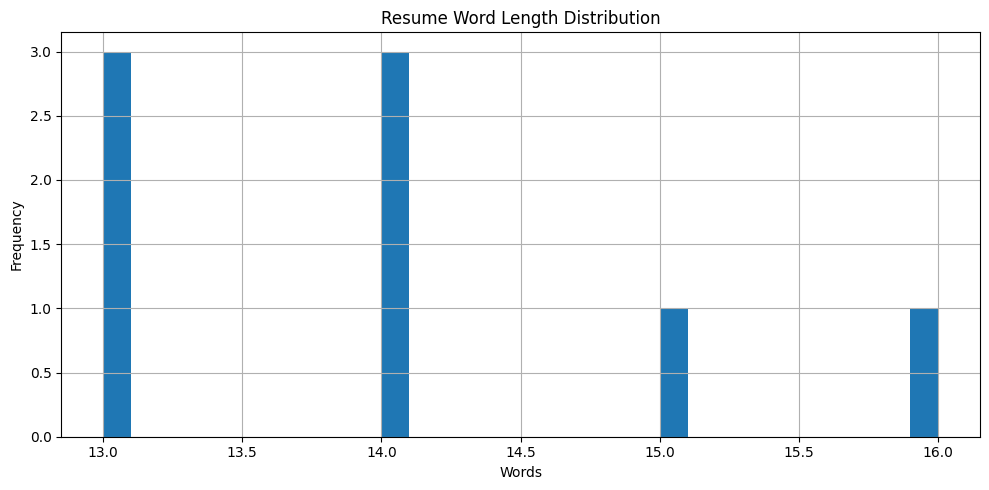

In [18]:
df["resume_word_len"].hist(bins=30)
plt.title("Resume Word Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Display Random Resume Samples**

In [19]:
df.sample(min(5, len(df)), random_state=SEED)[["category", "resume_text"]]

,category,resume_text
1,Data Science,Worked on analytics statistics machine learning feature engineering and dashboarding for business decision making.
5,Sales,Sales professional with business development client management lead generation negotiation and crm handling.
0,Data Science,Experienced data scientist with python machine learning sql power bi deep learning and model deployment experience.
7,Testing,QA engineer with manual testing automation selenium jira test cases regression and bug tracking.
2,HR,Human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience.


### **Define Text Cleaning Function**

In [20]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

### **Clean Resume Text**

In [21]:
df["resume_clean"] = df["resume_text"].apply(clean_text)
df[["resume_text", "resume_clean"]].head(3)

,resume_text,resume_clean
0,Experienced data scientist with python machine learning sql power bi deep learning and model deployment experience.,experienced data scientist with python machine learning sql power bi deep learning and model deployment experience
1,Worked on analytics statistics machine learning feature engineering and dashboarding for business decision making.,worked on analytics statistics machine learning feature engineering and dashboarding for business decision making
2,Human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience.,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience


### **Estimate Vocabulary Size in Resumes**

In [22]:
all_resume_tokens = " ".join(df["resume_clean"].tolist()).split()
resume_vocab_size = len(set(all_resume_tokens))
print("Estimated resume vocabulary size:", resume_vocab_size)

Estimated resume vocabulary size: 83


### **Inspect Most Common Resume Tokens**

In [23]:
from collections import Counter
pd.DataFrame(Counter(all_resume_tokens).most_common(20), columns=["token", "count"])

,token,count
0,and,8
1,with,6
2,learning,3
3,experience,3
4,automation,3
5,python,2
6,machine,2
7,sql,2
8,deployment,2
9,engineering,2


### **Create Job Description Templates by Category**

In [24]:
jd_template_map = {
    "data science": "Looking for a data science professional with machine learning, python, statistics, analytics, feature engineering, model deployment, sql and dashboarding experience.",
    "python developer": "Seeking a python developer with django, flask, api development, scripting, automation, pandas and backend engineering experience.",
    "java developer": "Hiring a java developer with spring boot, microservices, backend systems, api design, database and cloud deployment knowledge.",
    "devops engineer": "Need a devops engineer with docker, kubernetes, ci cd, aws, linux, monitoring and infrastructure automation experience.",
    "hr": "Looking for an hr professional with recruitment, onboarding, payroll, employee engagement, compliance and talent acquisition experience.",
    "sales": "Seeking a sales professional with lead generation, customer relationship management, negotiation, account handling and business development skills.",
    "testing": "Need a testing engineer with automation, selenium, test case design, regression testing and defect tracking expertise.",
}

### **Create Job Descriptions from Category**

In [25]:
def build_job_description(category):
    category_key = str(category).lower().strip()
    return jd_template_map.get(
        category_key,
        f"Looking for a professional in {category_key} with relevant domain expertise, communication skills, technical knowledge and practical experience."
    )

df["job_description"] = df["category"].apply(build_job_description)
df[["category", "job_description"]].head()

,category,job_description
0,Data Science,"Looking for a data science professional with machine learning, python, statistics, analytics, feature engineering, model deployment, sql and dashboarding experience."
1,Data Science,"Looking for a data science professional with machine learning, python, statistics, analytics, feature engineering, model deployment, sql and dashboarding experience."
2,HR,"Looking for an hr professional with recruitment, onboarding, payroll, employee engagement, compliance and talent acquisition experience."
3,Java Developer,"Hiring a java developer with spring boot, microservices, backend systems, api design, database and cloud deployment knowledge."
4,Python Developer,"Seeking a python developer with django, flask, api development, scripting, automation, pandas and backend engineering experience."


### **Create Job Description Length Features**

In [26]:
df["jd_char_len"] = df["job_description"].astype(str).str.len()
df["jd_word_len"] = df["job_description"].astype(str).str.split().str.len()
df[["jd_char_len", "jd_word_len"]].describe().T

,count,mean,std,min,25%,50%,75%,max
jd_char_len,8.0,138.125,19.007048,118.0,124.25,132.5,151.50,165.0
jd_word_len,8.0,17.250,1.752549,16.0,16.00,16.5,17.75,20.0


### **Display Resume and JD Pair Samples**

In [27]:
df[["category", "resume_clean", "job_description"]].head(5)

,category,resume_clean,job_description
0,Data Science,experienced data scientist with python machine learning sql power bi deep learning and model deployment experience,"Looking for a data science professional with machine learning, python, statistics, analytics, feature engineering, model deployment, sql and dashboarding experience."
1,Data Science,worked on analytics statistics machine learning feature engineering and dashboarding for business decision making,"Looking for a data science professional with machine learning, python, statistics, analytics, feature engineering, model deployment, sql and dashboarding experience."
2,HR,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,"Looking for an hr professional with recruitment, onboarding, payroll, employee engagement, compliance and talent acquisition experience."
3,Java Developer,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,"Hiring a java developer with spring boot, microservices, backend systems, api design, database and cloud deployment knowledge."
4,Python Developer,python developer with flask django pandas api development automation testing and scripting experience,"Seeking a python developer with django, flask, api development, scripting, automation, pandas and backend engineering experience."


### **Create Positive Resume–JD Pairs**

In [28]:
positive_pairs = []
for _, row in df.iterrows():
    positive_pairs.append({
        "resume_text": row["resume_clean"],
        "job_description": clean_text(row["job_description"]),
        "label": 1,
        "resume_category": row["category"],
        "jd_category": row["category"]
    })

positive_df = pd.DataFrame(positive_pairs)
positive_df.head()

,resume_text,job_description,label,resume_category,jd_category
0,experienced data scientist with python machine learning sql power bi deep learning and model deployment experience,looking for a data science professional with machine learning python statistics analytics feature engineering model deployment sql and dashboarding experience,1,Data Science,Data Science
1,worked on analytics statistics machine learning feature engineering and dashboarding for business decision making,looking for a data science professional with machine learning python statistics analytics feature engineering model deployment sql and dashboarding experience,1,Data Science,Data Science
2,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,looking for an hr professional with recruitment onboarding payroll employee engagement compliance and talent acquisition experience,1,HR,HR
3,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,hiring a java developer with spring boot microservices backend systems api design database and cloud deployment knowledge,1,Java Developer,Java Developer
4,python developer with flask django pandas api development automation testing and scripting experience,seeking a python developer with django flask api development scripting automation pandas and backend engineering experience,1,Python Developer,Python Developer


### **Create Negative Resume–JD Pairs**

In [29]:
negative_pairs = []
for idx, row in df.iterrows():
    mismatched_df = df[df["category"] != row["category"]]
    if len(mismatched_df) == 0:
        continue

    sampled_negatives = mismatched_df.sample(min(2, len(mismatched_df)), random_state=SEED + idx)
    for _, neg_row in sampled_negatives.iterrows():
        negative_pairs.append({
            "resume_text": row["resume_clean"],
            "job_description": clean_text(neg_row["job_description"]),
            "label": 0,
            "resume_category": row["category"],
            "jd_category": neg_row["category"]
        })

negative_df = pd.DataFrame(negative_pairs)
negative_df.head()

,resume_text,job_description,label,resume_category,jd_category
0,experienced data scientist with python machine learning sql power bi deep learning and model deployment experience,looking for an hr professional with recruitment onboarding payroll employee engagement compliance and talent acquisition experience,0,Data Science,HR
1,experienced data scientist with python machine learning sql power bi deep learning and model deployment experience,hiring a java developer with spring boot microservices backend systems api design database and cloud deployment knowledge,0,Data Science,Java Developer
2,worked on analytics statistics machine learning feature engineering and dashboarding for business decision making,need a testing engineer with automation selenium test case design regression testing and defect tracking expertise,0,Data Science,Testing
3,worked on analytics statistics machine learning feature engineering and dashboarding for business decision making,seeking a python developer with django flask api development scripting automation pandas and backend engineering experience,0,Data Science,Python Developer
4,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,need a devops engineer with docker kubernetes ci cd aws linux monitoring and infrastructure automation experience,0,HR,DevOps Engineer


### **Combine Positive and Negative Pairs**

In [30]:
pair_df = pd.concat([positive_df, negative_df], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(pair_df.shape)
pair_df.head()

(24, 5)


,resume_text,job_description,label,resume_category,jd_category
0,experienced data scientist with python machine learning sql power bi deep learning and model deployment experience,looking for an hr professional with recruitment onboarding payroll employee engagement compliance and talent acquisition experience,0,Data Science,HR
1,python developer with flask django pandas api development automation testing and scripting experience,hiring a java developer with spring boot microservices backend systems api design database and cloud deployment knowledge,0,Python Developer,Java Developer
2,experienced data scientist with python machine learning sql power bi deep learning and model deployment experience,looking for a data science professional with machine learning python statistics analytics feature engineering model deployment sql and dashboarding experience,1,Data Science,Data Science
3,sales professional with business development client management lead generation negotiation and crm handling,looking for an hr professional with recruitment onboarding payroll employee engagement compliance and talent acquisition experience,0,Sales,HR
4,worked on analytics statistics machine learning feature engineering and dashboarding for business decision making,seeking a python developer with django flask api development scripting automation pandas and backend engineering experience,0,Data Science,Python Developer


### **Inspect Pair Label Distribution**

In [31]:
pair_df["label"].value_counts()

label
0    16
1     8
Name: count, dtype: int64

### **Plot Pair Label Distribution**

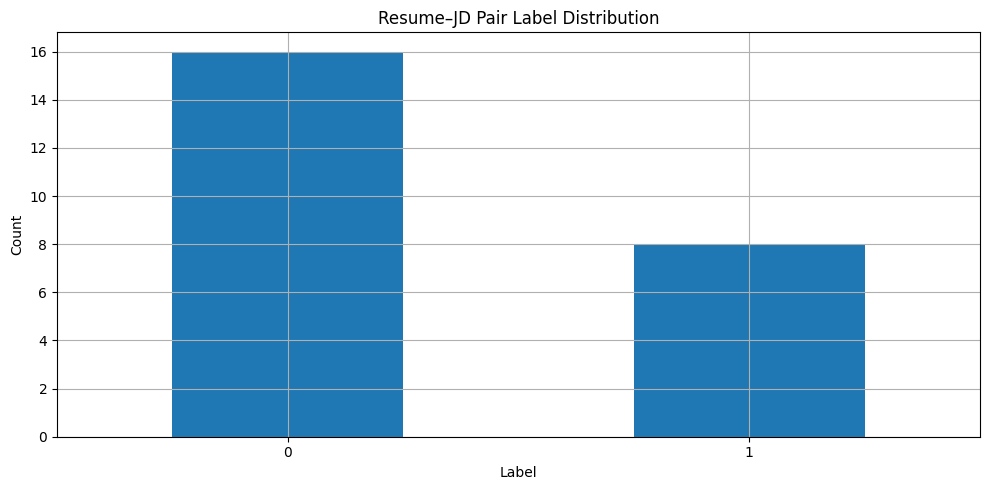

In [32]:
pair_df["label"].value_counts().plot(kind="bar")
plt.title("Resume–JD Pair Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Create Combined Corpus for Tokenization**

In [33]:
combined_texts = pair_df["resume_text"].tolist() + pair_df["job_description"].tolist()
print("Total text records for tokenization:", len(combined_texts))

Total text records for tokenization: 48


### **Initialize Tokenizer**

In [34]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(combined_texts)

print("Tokenizer fitted successfully.")

Tokenizer fitted successfully.


### **Inspect Vocabulary Size after Tokenization**

In [35]:
vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
print("Vocabulary size used:", vocab_size)

Vocabulary size used: 105


### **Convert Resume Text to Sequences**

In [36]:
pair_df["resume_seq"] = tokenizer.texts_to_sequences(pair_df["resume_text"].tolist())
pair_df["jd_seq"] = tokenizer.texts_to_sequences(pair_df["job_description"].tolist())
pair_df[["resume_seq", "jd_seq"]].head(2)

,resume_seq,jd_seq
0,"[76, 33, 77, 3, 10, 18, 12, 19, 78, 79, 80, 12, 2, 34, 7, 4]","[21, 14, 59, 60, 13, 3, 61, 24, 26, 25, 62, 27, 2, 22, 23, 4]"
1,"[10, 8, 3, 35, 36, 37, 9, 16, 6, 20, 2, 38, 4]","[63, 5, 28, 8, 3, 29, 30, 31, 15, 64, 9, 44, 65, 2, 32, 7, 66]"


### **Analyze Resume Sequence Lengths**

In [37]:
resume_seq_lengths = pair_df["resume_seq"].apply(len)
pd.Series(resume_seq_lengths).describe()

count    24.000000
mean     14.000000
std       1.021508
min      13.000000
25%      13.000000
50%      14.000000
75%      14.250000
max      16.000000
Name: resume_seq, dtype: float64

### **Analyze Job Description Sequence Lengths**

In [38]:
jd_seq_lengths = pair_df["jd_seq"].apply(len)
pd.Series(jd_seq_lengths).describe()

count    24.000000
mean     16.916667
std       1.471960
min      16.000000
25%      16.000000
50%      16.000000
75%      17.000000
max      20.000000
Name: jd_seq, dtype: float64

### **Plot Resume Sequence Length Distribution**

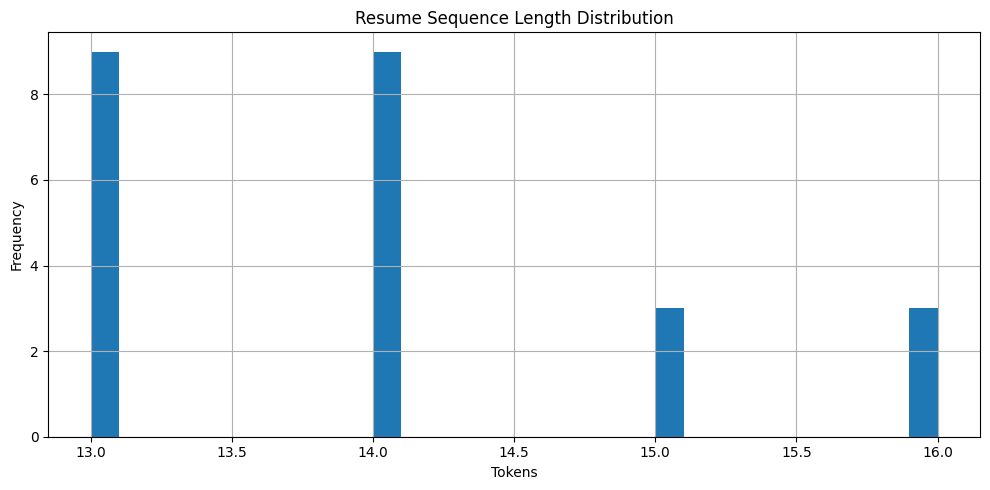

In [39]:
pd.Series(resume_seq_lengths).hist(bins=30)
plt.title("Resume Sequence Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Plot Job Description Sequence Length Distribution**

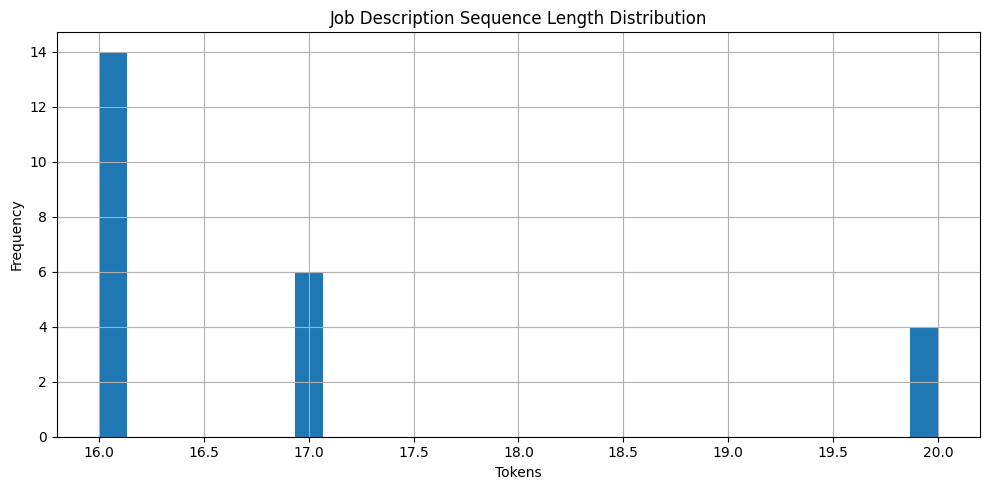

In [40]:
pd.Series(jd_seq_lengths).hist(bins=30)
plt.title("Job Description Sequence Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Pad Resume Sequences**

In [41]:
resume_padded = pad_sequences(
    pair_df["resume_seq"].tolist(),
    maxlen=MAX_RESUME_LEN,
    padding="post",
    truncating="post"
)

resume_padded.shape

(24, 300)

### **Pad Job Description Sequences**

In [42]:
jd_padded = pad_sequences(
    pair_df["jd_seq"].tolist(),
    maxlen=MAX_JD_LEN,
    padding="post",
    truncating="post"
)

jd_padded.shape

(24, 220)

### **Create Label Array**

In [43]:
labels = pair_df["label"].astype(int).values
labels[:10]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 1])

### **Split into Train and Temp Sets**

In [44]:
X_resume_train, X_resume_temp, X_jd_train, X_jd_temp, y_train, y_temp = train_test_split(
    resume_padded,
    jd_padded,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

print(X_resume_train.shape, X_resume_temp.shape)

(16, 300) (8, 300)


### **Split Temp into Validation and Test Sets**

In [45]:
X_resume_val, X_resume_test, X_jd_val, X_jd_test, y_val, y_test = train_test_split(
    X_resume_temp,
    X_jd_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(X_resume_val.shape, X_resume_test.shape)

(4, 300) (4, 300)


### **Create Helper DataFrames for Validation and Test Analysis**

In [46]:
train_meta_df, temp_meta_df = train_test_split(
    pair_df.reset_index(drop=True),
    test_size=0.30,
    random_state=SEED,
    stratify=pair_df["label"]
)

val_meta_df, test_meta_df = train_test_split(
    temp_meta_df.reset_index(drop=True),
    test_size=0.50,
    random_state=SEED,
    stratify=temp_meta_df["label"]
)

val_meta_df = val_meta_df.reset_index(drop=True)
test_meta_df = test_meta_df.reset_index(drop=True)

print(val_meta_df.shape, test_meta_df.shape)

(4, 7) (4, 7)


### **Define Shared BiLSTM Encoder**

In [47]:
def build_shared_encoder(max_len, vocab_size, embedding_dim, lstm_units, dropout_rate, name_prefix):
    text_input = Input(shape=(max_len,), name=f"{name_prefix}_input")
    x = Embedding(vocab_size, embedding_dim, name=f"{name_prefix}_embedding")(text_input)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True), name=f"{name_prefix}_bilstm")(x)
    x = GlobalMaxPooling1D(name=f"{name_prefix}_pool")(x)
    x = Dropout(dropout_rate, name=f"{name_prefix}_dropout")(x)
    x = Dense(128, activation="relu", name=f"{name_prefix}_dense")(x)
    return text_input, x

### **Create Resume Encoder Branch**

In [48]:
resume_input, resume_encoded = build_shared_encoder(
    MAX_RESUME_LEN,
    vocab_size,
    EMBEDDING_DIM,
    LSTM_UNITS,
    DROPOUT_RATE,
    "resume"
)

resume_input, resume_encoded

(<KerasTensor shape=(None, 300), dtype=float32, sparse=False, ragged=False, name=resume_input>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4>)

### **Create Job Description Encoder Branch**

In [49]:
jd_input, jd_encoded = build_shared_encoder(
    MAX_JD_LEN,
    vocab_size,
    EMBEDDING_DIM,
    LSTM_UNITS,
    DROPOUT_RATE,
    "jd"
)

jd_input, jd_encoded

(<KerasTensor shape=(None, 220), dtype=float32, sparse=False, ragged=False, name=jd_input>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>)

### **Create Similarity Features**

In [50]:
diff = Lambda(absolute_difference_fn, name="absolute_difference")([resume_encoded, jd_encoded])
mul = Lambda(elementwise_product_fn, name="elementwise_product")([resume_encoded, jd_encoded])

diff, mul

(<KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_13>,
 <KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_17>)

### **Concatenate Matching Features**

In [51]:
merged = Concatenate(name="merged_features")([resume_encoded, jd_encoded, diff, mul])
merged

<KerasTensor shape=(None, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>

### **Add Dense Matching Layers**

In [52]:
x = Dense(128, activation="relu", name="match_dense_1")(merged)
x = Dropout(0.30, name="match_dropout_1")(x)
x = Dense(64, activation="relu", name="match_dense_2")(x)
x = Dropout(0.20, name="match_dropout_2")(x)
output = Dense(1, activation="sigmoid", name="match_probability")(x)

output

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_23>

### **Build the Full BiLSTM Matching Model**

In [53]:
model = Model(inputs=[resume_input, jd_input], outputs=output, name="resume_jd_bilstm_matcher")
model.summary()

Model: "resume_jd_bilstm_matcher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ resume_input (InputLayer)     │ (None, 300)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ jd_input (InputLayer)         │ (None, 220)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resume_embedding (Embedding)  │ (None, 300, 128)          │          13,440 │ resume_input[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ jd_embedding (Embedding)      │ (None, 220, 128)          │          13,440 │ jd_input[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resume_bilstm (Bidirectional) │ (None, 300, 128)          │          98,816 │ resume_embedding[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ jd_bilstm (Bidirectional)     │ (None, 220, 128)          │          98,816 │ jd_embedding[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resume_pool                   │ (None, 128)               │               0 │ resume_bilstm[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ jd_pool (GlobalMaxPooling1D)  │ (None, 128)               │               0 │ jd_bilstm[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resume_dropout (Dropout)      │ (None, 128)               │               0 │ resume_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ jd_dropout (Dropout)          │ (None, 128)               │               0 │ jd_pool[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ resume_dense (Dense)          │ (None, 128)               │          16,512 │ resume_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ jd_dense (Dense)              │ (None, 128)               │          16,512 │ jd_dropout[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ absolute_difference (Lambda)  │ (None, 128)               │               0 │ resume_dense[0][0],        │
│                               │                           │                 │ jd_dense[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ elementwise_product (Lambda)  │ (None, 128)               │               0 │ resume_dense[0][0],        │
│                               │                           │                 │ jd_dense[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ merged_features (Concatenate) │ (None, 512)               │               0 │ resume_dense[0][0],        │
│                               │                           │                 │ jd_dense[0][0],            │
│                               │                           │               

 Total params: 331,521 (1.26 MB)

 Trainable params: 331,521 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

### **Print a Simple Model Architecture Diagram**

In [54]:
architecture_diagram = '''
Resume Text ─► Tokenizer ─► Embedding ─► BiLSTM ─► Pooling ─┐
                                                             ├─► Merge Features ─► Dense Layers ─► Match Score
Job Description ─► Tokenizer ─► Embedding ─► BiLSTM ─► Pooling ─┘
'''
print(architecture_diagram)


Resume Text ─► Tokenizer ─► Embedding ─► BiLSTM ─► Pooling ─┐
                                                             ├─► Merge Features ─► Dense Layers ─► Match Score
Job Description ─► Tokenizer ─► Embedding ─► BiLSTM ─► Pooling ─┘



### **Compile the Model**

In [55]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


### **Create Training Callbacks**

In [56]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    )
]

print("Callbacks ready.")

Callbacks ready.


### **Train the BiLSTM Matching Model**

In [57]:
history = model.fit(
    [X_resume_train, X_jd_train],
    y_train,
    validation_data=([X_resume_val, X_jd_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.7500 - loss: 0.6910 - val_accuracy: 0.5000 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 2/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6875 - loss: 0.6830 - val_accuracy: 0.5000 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 3/4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6875 - loss: 0.6695 - val_accuracy: 0.5000 - val_loss: 0.6958 - learning_rate: 5.0000e-04


### **Convert Training History to DataFrame**

In [58]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.7500,0.691003,0.5,0.692590,0.0010
1,0.6875,0.682955,0.5,0.694146,0.0010
2,0.6875,0.669544,0.5,0.695791,0.0005


### **Plot Training and Validation Loss**

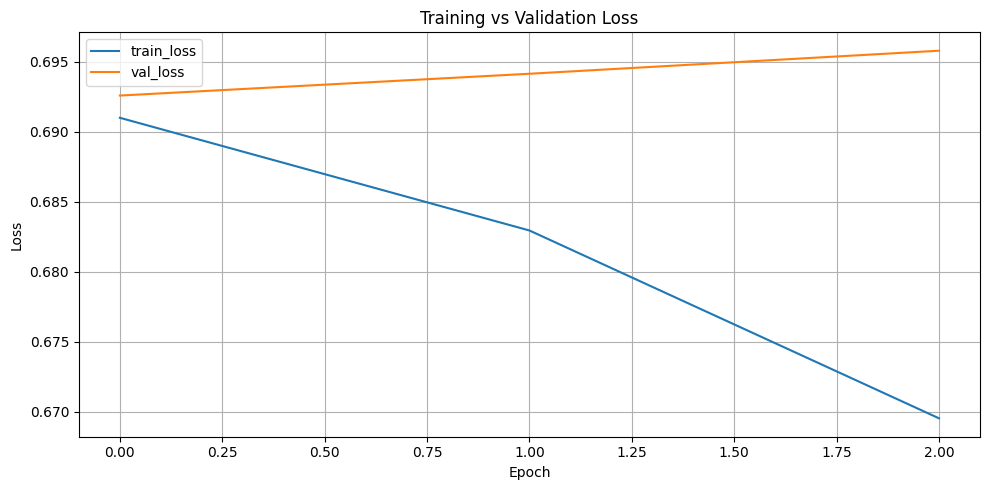

In [59]:
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### **Plot Training and Validation Accuracy**

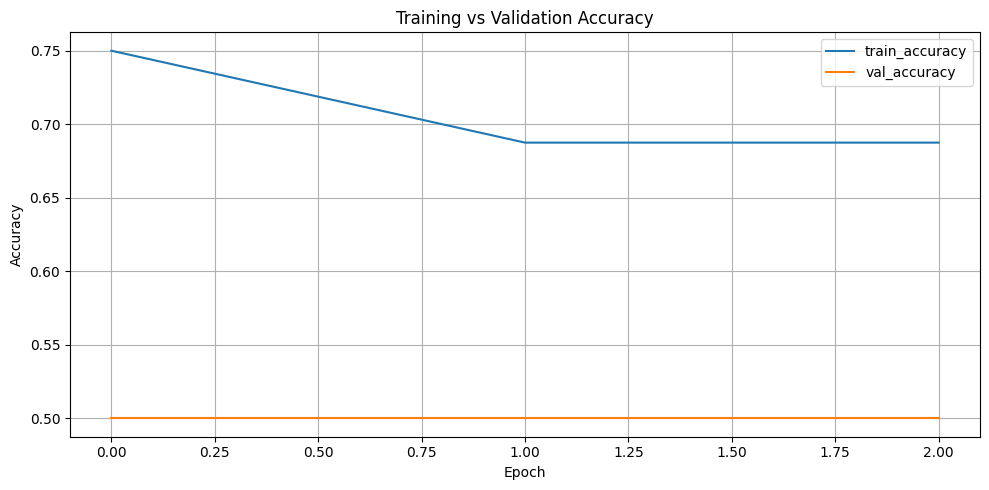

In [60]:
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### **Evaluate on the Test Set**

In [61]:
test_loss, test_accuracy = model.evaluate([X_resume_test, X_jd_test], y_test, verbose=0)
print({"test_loss": round(float(test_loss), 4), "test_accuracy": round(float(test_accuracy), 4)})

{'test_loss': 0.6843, 'test_accuracy': 0.75}


### **Generate Test Predictions**

In [62]:
y_pred_prob = model.predict([X_resume_test, X_jd_test], verbose=0).reshape(-1)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(y_pred[:10])
print(y_pred_prob[:10])

[0 0 0 0]
[0.48944134 0.4907516  0.4865568  0.4882016 ]


### **Compute Precision, Recall, and F1**

In [63]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="binary",
    zero_division=0
)

metrics_dict = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}
metrics_dict

{'accuracy': 0.75, 'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0}

### **Display Classification Report**

In [64]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



### **Plot Confusion Matrix**

In [65]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
cm_df

,Pred 0,Pred 1
Actual 0,3,0
Actual 1,1,0


### **Visualize Confusion Matrix as Heat-Style Table**

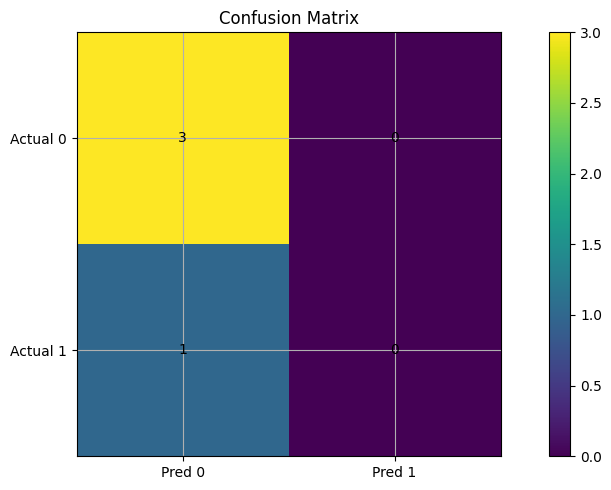

In [66]:
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### **Create Prediction Analysis DataFrame**

In [67]:
prediction_df = test_meta_df.copy().reset_index(drop=True)
prediction_df["true_label"] = y_test
prediction_df["pred_prob"] = y_pred_prob
prediction_df["pred_label"] = y_pred
prediction_df["is_correct"] = (prediction_df["true_label"] == prediction_df["pred_label"]).astype(int)
prediction_df["confidence"] = np.where(
    prediction_df["pred_label"] == 1,
    prediction_df["pred_prob"],
    1 - prediction_df["pred_prob"]
)
prediction_df.head()

,resume_text,job_description,label,resume_category,jd_category,resume_seq,jd_seq,true_label,pred_prob,pred_label,is_correct,confidence
0,qa engineer with manual testing automation selenium jira test cases regression and bug tracking,seeking a python developer with django flask api development scripting automation pandas and backend engineering experience,0,Testing,Python Developer,"[94, 17, 3, 95, 20, 6, 55, 96, 56, 97, 57, 2, 98, 58]","[67, 5, 10, 8, 3, 36, 35, 9, 16, 38, 6, 37, 2, 15, 11, 4]",0,0.489441,0,1,0.510559
1,python developer with flask django pandas api development automation testing and scripting experience,looking for a data science professional with machine learning python statistics analytics feature engineering model deployment sql and dashboarding experience,0,Python Developer,Data Science,"[10, 8, 3, 35, 36, 37, 9, 16, 6, 20, 2, 38, 4]","[21, 14, 5, 33, 75, 13, 3, 18, 12, 10, 41, 40, 42, 11, 34, 7, 19, 2, 43, 4]",0,0.490752,0,1,0.509248
2,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,hiring a java developer with spring boot microservices backend systems api design database and cloud deployment knowledge,1,Java Developer,Java Developer,"[28, 8, 3, 29, 30, 31, 93, 9, 19, 32, 7, 2, 15, 11, 54]","[63, 5, 28, 8, 3, 29, 30, 31, 15, 64, 9, 44, 65, 2, 32, 7, 66]",1,0.486557,0,0,0.513443
3,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,need a devops engineer with docker kubernetes ci cd aws linux monitoring and infrastructure automation experience,0,HR,DevOps Engineer,"[87, 88, 89, 3, 22, 23, 24, 25, 90, 26, 2, 27, 4]","[68, 5, 45, 17, 3, 48, 49, 46, 47, 50, 53, 51, 2, 52, 6, 4]",0,0.488202,0,1,0.511798


### **Review Most Confident Correct Predictions**

In [68]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[False, False]).head(10)

,resume_text,job_description,label,resume_category,jd_category,resume_seq,jd_seq,true_label,pred_prob,pred_label,is_correct,confidence
3,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,need a devops engineer with docker kubernetes ci cd aws linux monitoring and infrastructure automation experience,0,HR,DevOps Engineer,"[87, 88, 89, 3, 22, 23, 24, 25, 90, 26, 2, 27, 4]","[68, 5, 45, 17, 3, 48, 49, 46, 47, 50, 53, 51, 2, 52, 6, 4]",0,0.488202,0,1,0.511798
0,qa engineer with manual testing automation selenium jira test cases regression and bug tracking,seeking a python developer with django flask api development scripting automation pandas and backend engineering experience,0,Testing,Python Developer,"[94, 17, 3, 95, 20, 6, 55, 96, 56, 97, 57, 2, 98, 58]","[67, 5, 10, 8, 3, 36, 35, 9, 16, 38, 6, 37, 2, 15, 11, 4]",0,0.489441,0,1,0.510559
1,python developer with flask django pandas api development automation testing and scripting experience,looking for a data science professional with machine learning python statistics analytics feature engineering model deployment sql and dashboarding experience,0,Python Developer,Data Science,"[10, 8, 3, 35, 36, 37, 9, 16, 6, 20, 2, 38, 4]","[21, 14, 5, 33, 75, 13, 3, 18, 12, 10, 41, 40, 42, 11, 34, 7, 19, 2, 43, 4]",0,0.490752,0,1,0.509248
2,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,hiring a java developer with spring boot microservices backend systems api design database and cloud deployment knowledge,1,Java Developer,Java Developer,"[28, 8, 3, 29, 30, 31, 93, 9, 19, 32, 7, 2, 15, 11, 54]","[63, 5, 28, 8, 3, 29, 30, 31, 15, 64, 9, 44, 65, 2, 32, 7, 66]",1,0.486557,0,0,0.513443


### **Review Most Confident Incorrect Predictions**

In [69]:
prediction_df.sort_values(["is_correct", "confidence"], ascending=[True, False]).head(10)

,resume_text,job_description,label,resume_category,jd_category,resume_seq,jd_seq,true_label,pred_prob,pred_label,is_correct,confidence
2,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,hiring a java developer with spring boot microservices backend systems api design database and cloud deployment knowledge,1,Java Developer,Java Developer,"[28, 8, 3, 29, 30, 31, 93, 9, 19, 32, 7, 2, 15, 11, 54]","[63, 5, 28, 8, 3, 29, 30, 31, 15, 64, 9, 44, 65, 2, 32, 7, 66]",1,0.486557,0,0,0.513443
3,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,need a devops engineer with docker kubernetes ci cd aws linux monitoring and infrastructure automation experience,0,HR,DevOps Engineer,"[87, 88, 89, 3, 22, 23, 24, 25, 90, 26, 2, 27, 4]","[68, 5, 45, 17, 3, 48, 49, 46, 47, 50, 53, 51, 2, 52, 6, 4]",0,0.488202,0,1,0.511798
0,qa engineer with manual testing automation selenium jira test cases regression and bug tracking,seeking a python developer with django flask api development scripting automation pandas and backend engineering experience,0,Testing,Python Developer,"[94, 17, 3, 95, 20, 6, 55, 96, 56, 97, 57, 2, 98, 58]","[67, 5, 10, 8, 3, 36, 35, 9, 16, 38, 6, 37, 2, 15, 11, 4]",0,0.489441,0,1,0.510559
1,python developer with flask django pandas api development automation testing and scripting experience,looking for a data science professional with machine learning python statistics analytics feature engineering model deployment sql and dashboarding experience,0,Python Developer,Data Science,"[10, 8, 3, 35, 36, 37, 9, 16, 6, 20, 2, 38, 4]","[21, 14, 5, 33, 75, 13, 3, 18, 12, 10, 41, 40, 42, 11, 34, 7, 19, 2, 43, 4]",0,0.490752,0,1,0.509248


### **Analyze Errors by Resume Category**

In [70]:
prediction_df.groupby("resume_category")["is_correct"].mean().sort_values()

resume_category
Java Developer      0.0
HR                  1.0
Python Developer    1.0
Testing             1.0
Name: is_correct, dtype: float64

### **Plot Error Analysis by Resume Category**

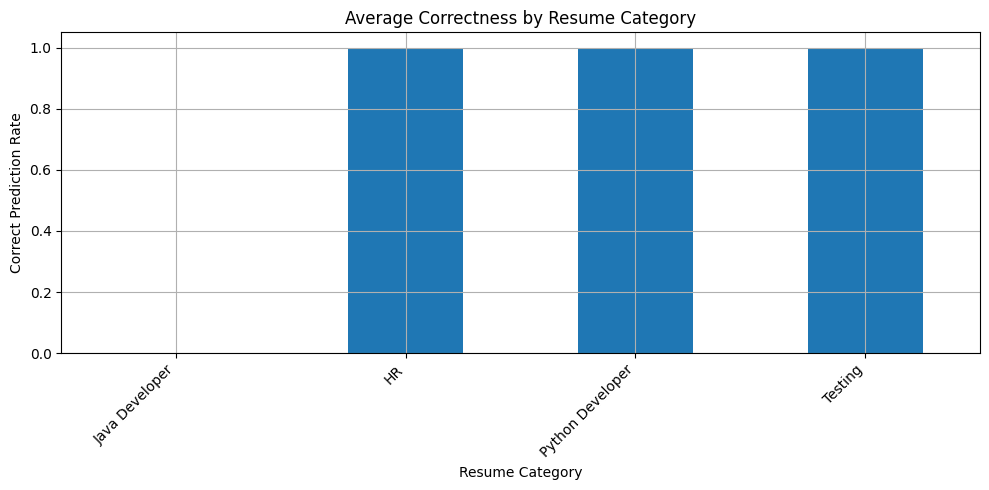

In [71]:
prediction_df.groupby("resume_category")["is_correct"].mean().sort_values().plot(kind="bar")
plt.title("Average Correctness by Resume Category")
plt.xlabel("Resume Category")
plt.ylabel("Correct Prediction Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **Create Resume and Job Encoders for Similarity Search**

In [72]:
resume_encoder = Model(inputs=model.input[0], outputs=model.get_layer("resume_dense").output)
jd_encoder = Model(inputs=model.input[1], outputs=model.get_layer("jd_dense").output)

print("Encoder models created.")

Encoder models created.


### **Build Candidate Resume Embeddings**

In [73]:
candidate_resume_df = df[["category", "resume_clean"]].drop_duplicates().reset_index(drop=True)
candidate_resume_seq = tokenizer.texts_to_sequences(candidate_resume_df["resume_clean"].tolist())
candidate_resume_pad = pad_sequences(candidate_resume_seq, maxlen=MAX_RESUME_LEN, padding="post", truncating="post")

resume_embeddings = resume_encoder.predict(candidate_resume_pad, verbose=0)
resume_embeddings.shape

(8, 128)

### **Define Job Description Encoding Utility**

In [74]:
def encode_job_description(job_text):
    cleaned = clean_text(job_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_JD_LEN, padding="post", truncating="post")
    emb = jd_encoder.predict(pad, verbose=0)
    return emb

### **Run a Sample Top-K Resume Retrieval**

In [75]:
sample_jd = "Looking for a data science professional with machine learning python analytics sql and dashboarding experience."
jd_emb = encode_job_description(sample_jd)

scores = cosine_similarity(jd_emb, resume_embeddings)[0]
candidate_resume_df["similarity_score"] = scores
candidate_resume_df.sort_values("similarity_score", ascending=False).head(TOP_K)

,category,resume_clean,similarity_score
2,HR,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,0.265001
3,Java Developer,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,0.261870
7,Testing,qa engineer with manual testing automation selenium jira test cases regression and bug tracking,0.250507
6,DevOps Engineer,devops engineer skilled in ci cd docker kubernetes aws monitoring infrastructure automation and linux,0.249482
5,Sales,sales professional with business development client management lead generation negotiation and crm handling,0.248983


### **Define Top-K Ranking Utility**

In [76]:
def rank_resumes_for_job(job_text, top_k=5):
    jd_emb = encode_job_description(job_text)
    sim_scores = cosine_similarity(jd_emb, resume_embeddings)[0]

    result_df = candidate_resume_df.copy()
    result_df["similarity_score"] = sim_scores
    result_df = result_df.sort_values("similarity_score", ascending=False).head(top_k).reset_index(drop=True)
    return result_df

### **Test the Ranking Utility**

In [77]:
rank_resumes_for_job(
    "Need a python developer with flask django automation scripting and api development experience.",
    top_k=min(TOP_K, len(candidate_resume_df))
)

,category,resume_clean,similarity_score
0,HR,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,0.281593
1,Java Developer,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,0.275111
2,Testing,qa engineer with manual testing automation selenium jira test cases regression and bug tracking,0.269146
3,Sales,sales professional with business development client management lead generation negotiation and crm handling,0.267528
4,DevOps Engineer,devops engineer skilled in ci cd docker kubernetes aws monitoring infrastructure automation and linux,0.265716


### **Create Ranking Evaluation Set by Category**

In [78]:
unique_jds = df[["category", "job_description"]].drop_duplicates().reset_index(drop=True)
unique_jds.head()

,category,job_description
0,Data Science,"Looking for a data science professional with machine learning, python, statistics, analytics, feature engineering, model deployment, sql and dashboarding experience."
1,HR,"Looking for an hr professional with recruitment, onboarding, payroll, employee engagement, compliance and talent acquisition experience."
2,Java Developer,"Hiring a java developer with spring boot, microservices, backend systems, api design, database and cloud deployment knowledge."
3,Python Developer,"Seeking a python developer with django, flask, api development, scripting, automation, pandas and backend engineering experience."
4,Sales,"Seeking a sales professional with lead generation, customer relationship management, negotiation, account handling and business development skills."


### **Evaluate Category-Based Top-K Matching**

In [79]:
topk_results = []

for _, row in unique_jds.iterrows():
    ranked_df = rank_resumes_for_job(row["job_description"], top_k=min(TOP_K, len(candidate_resume_df)))
    match_found = int(any(ranked_df["category"].str.lower() == str(row["category"]).lower()))
    topk_results.append({
        "job_category": row["category"],
        "match_found_in_top_k": match_found
    })

topk_eval_df = pd.DataFrame(topk_results)
topk_eval_df

,job_category,match_found_in_top_k
0,Data Science,0
1,HR,1
2,Java Developer,1
3,Python Developer,1
4,Sales,1
5,DevOps Engineer,1
6,Testing,1


### **Compute Recall@K for Category Matching**

In [80]:
recall_at_k = topk_eval_df["match_found_in_top_k"].mean()
print({f"recall_at_{TOP_K}": round(float(recall_at_k), 4)})

{'recall_at_5': 0.8571}


### **Save Model Artifacts**

In [81]:
model.save(MODEL_DIR / "resume_jd_bilstm_model.keras")
with open(ARTIFACT_DIR / "tokenizer_config.json", "w", encoding="utf-8") as f:
    json.dump(tokenizer.to_json(), f)

print("Model saved successfully.")

Model saved successfully.


### **Save Prediction Outputs**

In [82]:
prediction_df.to_csv(PRED_DIR / "resume_jd_prediction_analysis.csv", index=False)
topk_eval_df.to_csv(PRED_DIR / "resume_jd_topk_eval.csv", index=False)

print("Prediction outputs saved.")

Prediction outputs saved.


### **Reload the Saved Model**

In [83]:
reloaded_model = tf.keras.models.load_model(
    MODEL_DIR / "resume_jd_bilstm_model.keras",
    custom_objects={
        "absolute_difference_fn": absolute_difference_fn,
        "elementwise_product_fn": elementwise_product_fn,
    },
    safe_mode=False
)
print("Reloaded model successfully.")

Reloaded model successfully.


### **Run Reload Validation**

In [84]:
reload_probs = reloaded_model.predict([X_resume_test[:10], X_jd_test[:10]], verbose=0).reshape(-1)
reload_probs[:5]

array([0.48944134, 0.4907516 , 0.4865568 , 0.4882016 ], dtype=float32)

### **Create Deployment Demo Function**

In [85]:
def resume_match_demo(job_text, top_k=5):
    ranked = rank_resumes_for_job(job_text, top_k=top_k)
    return ranked[["category", "resume_clean", "similarity_score"]]

### **Test Deployment Demo Function**

In [86]:
resume_match_demo(
    "Hiring a devops engineer with aws kubernetes docker ci cd and linux expertise.",
    top_k=min(TOP_K, len(candidate_resume_df))
)

,category,resume_clean,similarity_score
0,HR,human resources specialist with talent acquisition onboarding employee relations payroll and compliance experience,0.296693
1,Testing,qa engineer with manual testing automation selenium jira test cases regression and bug tracking,0.292250
2,Java Developer,java developer with spring boot microservices rest api sql cloud deployment and backend engineering expertise,0.291870
3,DevOps Engineer,devops engineer skilled in ci cd docker kubernetes aws monitoring infrastructure automation and linux,0.280069
4,Python Developer,python developer with flask django pandas api development automation testing and scripting experience,0.279374


### **Create Optional Streamlit App Code**

In [87]:
streamlit_app_code = '''
import streamlit as st
import pandas as pd

st.title("Resume–JD Matching Demo")
job_text = st.text_area("Enter Job Description")

if st.button("Rank Resumes"):
    st.write("Integrate saved model inference here and show ranked resumes.")
'''
print(streamlit_app_code)


import streamlit as st
import pandas as pd

st.title("Resume–JD Matching Demo")
job_text = st.text_area("Enter Job Description")

if st.button("Rank Resumes"):
    st.write("Integrate saved model inference here and show ranked resumes.")



### **Final Project Summary for Notebook Report**

In [88]:
final_project_notes = {
    "project_title": "Resume–Job Description Matching System using Bi-Directional LSTM",
    "dataset": "PromptCloudHQ Resume Dataset",
    "model_type": "BiLSTM + similarity scoring",
    "core_goal": "Rank resumes for a job description using contextual sequence representations.",
    "deployment_ready": True,
    "includes_demo": True
}
final_project_notes

{'project_title': 'Resume–Job Description Matching System using Bi-Directional LSTM',
 'dataset': 'PromptCloudHQ Resume Dataset',
 'model_type': 'BiLSTM + similarity scoring',
 'core_goal': 'Rank resumes for a job description using contextual sequence representations.',
 'deployment_ready': True,
 'includes_demo': True}

### **Conclusion**

In [89]:
print(
    "This notebook built an end-to-end BiLSTM resume ranking workflow with dataset analysis, "
    "synthetic pair construction, sequence preprocessing, BiLSTM similarity modeling, "
    "classification and ranking evaluation, error analysis, and an optional deployment demo."
)

This notebook built an end-to-end BiLSTM resume ranking workflow with dataset analysis, synthetic pair construction, sequence preprocessing, BiLSTM similarity modeling, classification and ranking evaluation, error analysis, and an optional deployment demo.
